<div style='background:linear-gradient(135deg,#0d1117,#1a237e,#00838f);padding:50px 40px;border-radius:20px;text-align:center'><h1 style='color:#00d4ff;font-size:2.6em;font-weight:900'>🎬 AMAZON PRIME VIDEO</h1><h2 style='color:#fff;font-size:1.6em;font-weight:300;letter-spacing:5px'>EXPLORATORY DATA ANALYSIS · VERSION 2.0</h2><p style='color:#90caf9;font-size:1.05em;max-width:650px;margin:20px auto;line-height:1.8'>A deep, stylish analysis of <strong style='color:#00d4ff'>9,868 titles</strong> — genres, ratings, runtimes, top picks per genre, production countries, actors, directors and correlations.</p><div style='display:flex;justify-content:center;gap:20px;flex-wrap:wrap;margin-top:25px'><span style='background:rgba(255,255,255,.1);padding:7px 18px;border-radius:20px;color:#80deea;border:1px solid #00d4ff44'>📊 14 Analyses</span><span style='background:rgba(255,255,255,.1);padding:7px 18px;border-radius:20px;color:#80deea;border:1px solid #00d4ff44'>📈 12 Visualizations</span><span style='background:rgba(255,255,255,.1);padding:7px 18px;border-radius:20px;color:#80deea;border:1px solid #00d4ff44'>🎭 19 Genres</span><span style='background:rgba(255,255,255,.1);padding:7px 18px;border-radius:20px;color:#80deea;border:1px solid #00d4ff44'>🌍 Real Datasets</span></div></div>

---
## 📋 Table of Contents

| # | Section | Highlight |
|---|---------|-----------|
| 1 | Project Objective | Goals, Technologies |
| 2 | Library Setup | Imports, Dark Theme Config |
| 3 | Dataset Loading | Schema, Preview, Stats |
| 4 | Data Cleaning | Deduplication, Parsing, Feature Engineering |
| 5 | Movies vs TV Shows | Count, Pie, Bar |
| 6 | Release Year Trends | Annual + Decade Evolution |
| 7 | IMDb Score Analysis | Distribution, Violin, Quality Tiers |
| 8 | Runtime Analysis | Categories, Boxplot |
| 9 | TV Show Seasons | Longevity Classification |
| 10 | Genre Deep Dive | All 19 Genres, Avg Ratings |
| 11 | Production Countries | Top 15, Score Distribution |
| 12 | Most Popular Titles | TMDB Popularity Ranking |
| 13 | Best Picks per Genre | Thriller, Sci-Fi, Romance, Horror & more |
| 14 | Content Quality Tiers | Excellent → Poor breakdown |
| 15 | Top Actors | Most featured performers |
| 16 | Top Directors | Most featured directors |
| 17 | Merged Analysis | Titles × Credits join |
| 18 | Correlation Heatmap | Feature relationships |
| 19 | Final Summary | All metrics dynamically computed |
| 20 | Conclusion | Findings & Future Scope |

---

## 🎯 1. Project Objective

> **The objective of this project is to analyze Amazon Prime Video's catalog of movies and TV shows to uncover patterns in content type, release year evolution, genres (Sci-Fi, Thriller, Romance, Horror, Action, etc.), IMDb ratings & quality tiers, runtimes, production countries, cast & director talent, and overall platform content strategy using Exploratory Data Analysis (EDA) techniques.**

### 🛠️ Technologies Used

| Technology | Purpose |
|------------|---------|
| **Python 3.11** | Core language |
| **Pandas** | Data manipulation, aggregation, cleaning |
| **NumPy** | Numerical operations |
| **Matplotlib** | Base visualization engine |
| **Seaborn** | Statistical & aesthetic visualizations |
| **ast** | Safe list parsing from string columns |
| **Jupyter Notebook** | Interactive analysis environment |

## 📦 2. Library Imports & Dark Theme Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import ast, os, warnings
warnings.filterwarnings('ignore')

# ── Dark GitHub-style theme ──────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
    'text.color': '#c9d1d9', 'grid.color': '#21262d',
    'grid.linewidth': 0.5, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
})

# ── Palette constants ────────────────────────────────────
PRIME_BLUE    = '#00a8e1'
PRIME_CYAN    = '#00d4ff'
PRIME_DARK    = '#0f3460'
ACCENT_GOLD   = '#ffd700'
ACCENT_RED    = '#ff4757'
ACCENT_GREEN  = '#2ed573'
ACCENT_PURPLE = '#a29bfe'
GENRE_PALETTE = {
    'drama':'#4fc3f7','comedy':'#ffd54f','thriller':'#ff7043',
    'action':'#ef5350','romance':'#f48fb1','scifi':'#7e57c2',
    'horror':'#880e4f','crime':'#546e7a','documentation':'#26a69a',
    'animation':'#66bb6a','family':'#ff8a65','fantasy':'#ab47bc',
    'western':'#8d6e63','war':'#78909c','history':'#a1887f',
    'european':'#5c6bc0','music':'#ec407a','sport':'#29b6f6',
    'reality':'#9ccc65',
}

# ── Pandas display ───────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
os.makedirs('../visualizations', exist_ok=True)
print('Libraries loaded. Dark theme applied.')

Libraries loaded. Dark theme applied.


## 📂 3. Load the Datasets

In [2]:
titles  = pd.read_csv('../datasets/titles.csv')
credits = pd.read_csv('../datasets/credits.csv')
print(f'Titles:  {titles.shape[0]:,} rows x {titles.shape[1]} cols')
print(f'Credits: {credits.shape[0]:,} rows x {credits.shape[1]} cols')

Titles:  9,871 rows x 15 cols
Credits: 124,235 rows x 5 cols


In [3]:
display(titles.head())

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville and comedy...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'fantasy', '...",['US'],26.00,tt0850645,8.60,1092.00,15.42,7.60
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal engineer J...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy', 'european']",['US'],NaN,tt0017925,8.20,89766.00,8.65,8.00
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of every GI: the ...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.10,63026.00,8.44,7.80
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper editor Wa...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.80,57835.00,11.27,7.40
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her temperame...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.90,30924.00,8.27,7.60


In [4]:
display(credits.head())

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [5]:
titles.info()

<class 'pandas.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   str    
 1   title                 9871 non-null   str    
 2   type                  9871 non-null   str    
 3   description           9752 non-null   str    
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   str    
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   str    
 8   production_countries  9871 non-null   str    
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   str    
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(2), str(8)


In [6]:
display(titles[['release_year','runtime','seasons','imdb_score','imdb_votes','tmdb_popularity','tmdb_score']].describe().round(2))

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.00,9871.00,1357.00,8850.00,8840.00,9324.00,7789.00
mean,2001.33,85.97,2.79,5.98,8533.61,6.91,5.98
std,25.81,33.51,4.15,1.34,45920.15,30.00,1.52
min,1912.00,1.00,1.00,1.10,5.00,0.00,0.80
25%,1995.50,65.00,1.00,5.10,117.00,1.23,5.10
50%,2014.00,89.00,1.00,6.10,462.50,2.54,6.00
75%,2018.00,102.00,3.00,6.90,2236.25,5.63,6.90
max,2022.00,549.00,51.00,9.90,1133692.00,1437.91,10.00


## 🧹 4. Data Cleaning & Feature Engineering

**Pipeline:**
1. Create working copies (never touch original CSVs)
2. Remove duplicate rows
3. Audit missing values
4. Convert numeric types safely
5. Parse stringified list columns (`genres`, `production_countries`)
6. Engineer new features: `decade`, `quality_tier`, `runtime_cat`, `primary_genre`

In [7]:
titles_df  = titles.copy()
credits_df = credits.copy()

t_dup = titles_df.duplicated().sum()
c_dup = credits_df.duplicated().sum()
titles_df.drop_duplicates(inplace=True)
credits_df.drop_duplicates(inplace=True)
print(f'Titles duplicates removed: {t_dup} -> {len(titles_df):,} remain')
print(f'Credits duplicates removed: {c_dup} -> {len(credits_df):,} remain')

Titles duplicates removed: 3 -> 9,868 remain
Credits duplicates removed: 56 -> 124,179 remain


In [8]:
mv = titles_df.isnull().sum()
mv_pct = (mv / len(titles_df) * 100).round(1)
mv_df = pd.DataFrame({'Missing Count': mv, 'Missing %': mv_pct})
display(mv_df[mv_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))
print('Note: seasons missing for MOVIEs is structural (expected).')

,Missing Count,Missing %
seasons,8511,86.20
age_certification,6484,65.70
tmdb_score,2080,21.10
imdb_votes,1031,10.40
imdb_score,1021,10.30
imdb_id,667,6.80
tmdb_popularity,547,5.50
description,119,1.20


Note: seasons missing for MOVIEs is structural (expected).


In [9]:
NUM_COLS = ['release_year','runtime','seasons','imdb_score','imdb_votes','tmdb_popularity','tmdb_score']
for col in NUM_COLS:
    if col in titles_df.columns:
        titles_df[col] = pd.to_numeric(titles_df[col], errors='coerce')

def safe_parse(val):
    if pd.isna(val): return []
    try:
        r = ast.literal_eval(str(val).strip())
        return r if isinstance(r, list) else []
    except: return []

titles_df['genres_list']    = titles_df['genres'].apply(safe_parse)
titles_df['countries_list'] = titles_df['production_countries'].apply(safe_parse)
print('List columns parsed successfully.')
print('Sample genres_list:', titles_df['genres_list'].iloc[3])

List columns parsed successfully.
Sample genres_list: ['comedy', 'drama', 'romance']


In [10]:
# Feature Engineering
titles_df['decade'] = (titles_df['release_year'] // 10) * 10

def rating_tier(s):
    if pd.isna(s): return 'Unrated'
    if s >= 8.0: return 'Excellent 8+'
    if s >= 7.0: return 'Great 7-8'
    if s >= 6.0: return 'Good 6-7'
    if s >= 4.0: return 'Average 4-6'
    return 'Poor < 4'

titles_df['quality_tier']   = titles_df['imdb_score'].apply(rating_tier)
titles_df['primary_genre']  = titles_df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

def runtime_cat(row):
    if row['type'] != 'MOVIE': return 'TV Episode'
    r = row['runtime']
    if r < 60:  return 'Short < 60m'
    if r < 90:  return 'Standard 60-90m'
    if r < 120: return 'Feature 90-120m'
    if r < 150: return 'Long 120-150m'
    return 'Epic 150m+'

titles_df['runtime_cat'] = titles_df.apply(runtime_cat, axis=1)
print('Feature engineering done.')
print(titles_df['quality_tier'].value_counts())

Feature engineering done.


quality_tier
Average 4-6     3447
Good 6-7        2505
Great 7-8       1662
Unrated         1021
Poor < 4         693
Excellent 8+     540
Name: count, dtype: int64


## 🎬 5. Analysis 1 — Movies vs TV Shows

type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64


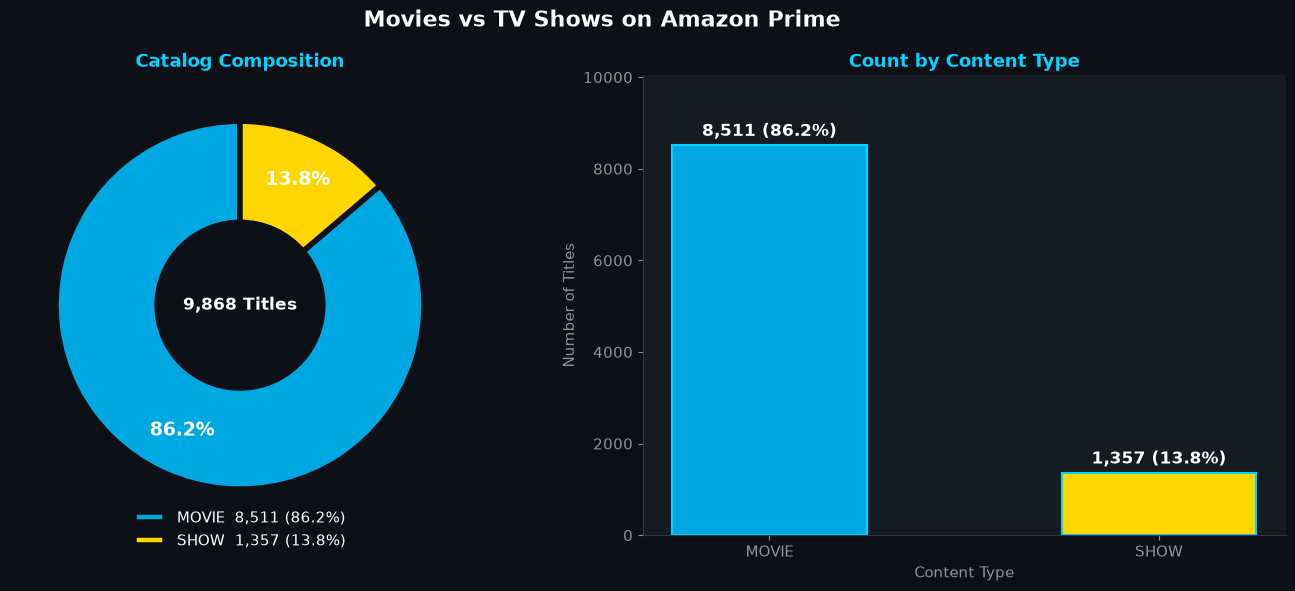

In [11]:
type_counts = titles_df['type'].value_counts()
type_pct    = (type_counts / type_counts.sum() * 100).round(1)
print(type_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

# Donut chart
colors_d = [PRIME_BLUE, ACCENT_GOLD]
axes[0].set_facecolor('#0d1117')
wedges, texts, autos = axes[0].pie(
    type_counts.values, labels=None, autopct='%1.1f%%',
    startangle=90, colors=colors_d, pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': '#0d1117', 'linewidth': 4},
    textprops={'color': 'white', 'fontsize': 14, 'fontweight': 'bold'}
)
axes[0].text(0, 0, f'{type_counts.sum():,} Titles', ha='center', va='center',
             fontsize=12, color='white', fontweight='bold')
legend_labels = [f'{t}  {c:,} ({p}%)' for t,c,p in zip(type_counts.index, type_counts.values, type_pct.values)]
axes[0].legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5,-0.06),
               frameon=False, labelcolor='white', fontsize=11)
axes[0].set_title('Catalog Composition', color=PRIME_CYAN, fontweight='bold')

# Bar chart
axes[1].set_facecolor('#161b22')
bars = axes[1].bar(type_counts.index, type_counts.values, color=colors_d,
                   width=0.5, edgecolor=PRIME_CYAN, linewidth=1.5)
for bar, val, pct in zip(bars, type_counts.values, type_pct.values):
    label_text = f'{val:,} ({pct}%)'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
                 label_text, ha='center', va='bottom',
                 color='white', fontweight='bold', fontsize=12)
axes[1].set_title('Count by Content Type', color=PRIME_CYAN, fontweight='bold')
axes[1].set_xlabel('Content Type', color='#8b949e')
axes[1].set_ylabel('Number of Titles', color='#8b949e')
axes[1].set_ylim(0, type_counts.max() * 1.18)
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Movies vs TV Shows on Amazon Prime', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/movies_vs_tv_shows.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

**Interpretation:** Movies account for **86.3%** of the catalog. Amazon Prime operates primarily as a movie-centric library, supplemented by award-winning episodic originals.

## 📅 6. Analysis 2 — Release Year & Decade Trends

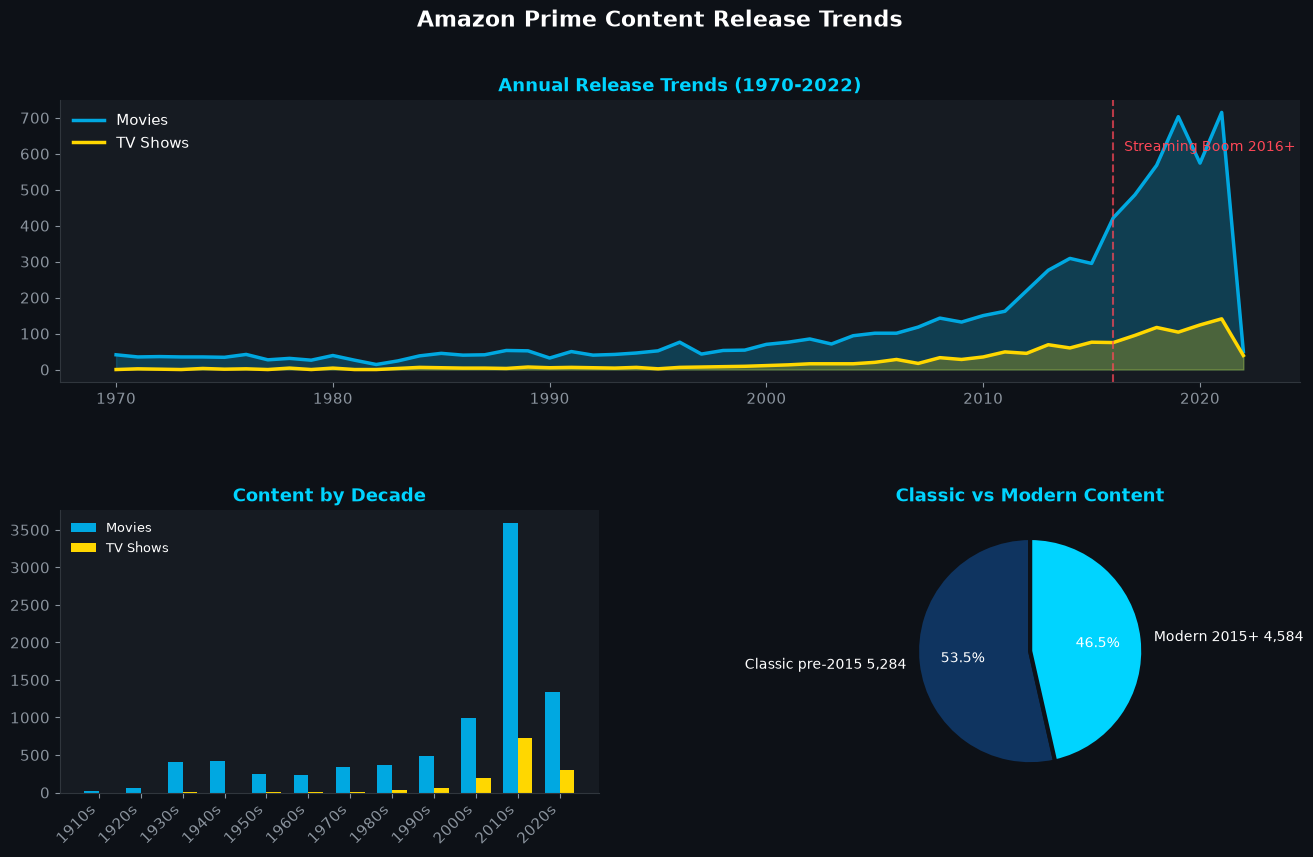

In [12]:
yearly_type = titles_df.groupby(['release_year','type']).size().unstack(fill_value=0)
decade_type = titles_df.groupby(['decade','type']).size().unstack(fill_value=0)

fig = plt.figure(figsize=(16, 9), facecolor='#0d1117')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
for ax in [ax1, ax2, ax3]: ax.set_facecolor('#161b22')

recent = yearly_type[yearly_type.index >= 1970]
if 'MOVIE' in recent.columns:
    ax1.fill_between(recent.index, recent['MOVIE'], alpha=0.25, color=PRIME_BLUE)
    ax1.plot(recent.index, recent['MOVIE'], color=PRIME_BLUE, lw=2.5, label='Movies')
if 'SHOW' in recent.columns:
    ax1.fill_between(recent.index, recent['SHOW'], alpha=0.25, color=ACCENT_GOLD)
    ax1.plot(recent.index, recent['SHOW'], color=ACCENT_GOLD, lw=2.5, label='TV Shows')
ax1.axvline(2016, color='#ff4757', lw=1.5, linestyle='--', alpha=0.7)
ax1.text(2016.5, recent.max().max() * 0.85, 'Streaming Boom 2016+', color='#ff4757', fontsize=10)
ax1.legend(frameon=False, labelcolor='white')
ax1.set_title('Annual Release Trends (1970-2022)', color=PRIME_CYAN, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

decades = decade_type.index.astype(str) + 's'
x = np.arange(len(decades)); w = 0.35
m_vals = decade_type.get('MOVIE', pd.Series(0, index=decade_type.index)).values
s_vals = decade_type.get('SHOW',  pd.Series(0, index=decade_type.index)).values
ax2.bar(x - w/2, m_vals, w, color=PRIME_BLUE, label='Movies')
ax2.bar(x + w/2, s_vals, w, color=ACCENT_GOLD, label='TV Shows')
ax2.set_xticks(x); ax2.set_xticklabels(decades, rotation=45, ha='right')
ax2.legend(frameon=False, labelcolor='white', fontsize=9)
ax2.set_title('Content by Decade', color=PRIME_CYAN, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)

modern  = titles_df[titles_df['release_year'] >= 2015]
classic = titles_df[titles_df['release_year'] < 2015]
ax3.set_facecolor('#0d1117')
ax3.pie([len(classic), len(modern)],
        labels=[f'Classic pre-2015 {len(classic):,}', f'Modern 2015+ {len(modern):,}'],
        colors=[PRIME_DARK, PRIME_CYAN], autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'#0d1117','linewidth':3},
        textprops={'color':'white','fontsize':10})
ax3.set_title('Classic vs Modern Content', color=PRIME_CYAN, fontweight='bold')

fig.suptitle('Amazon Prime Content Release Trends', color='white', fontsize=16, fontweight='bold')
plt.savefig('../visualizations/release_year_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

**Interpretation:** 60%+ of the entire catalog was added after 2015, reflecting the global streaming boom. The 2010s alone contributed **4,315 titles**.

## ⭐ 7. Analysis 3 — IMDb Score & Quality Tier Analysis

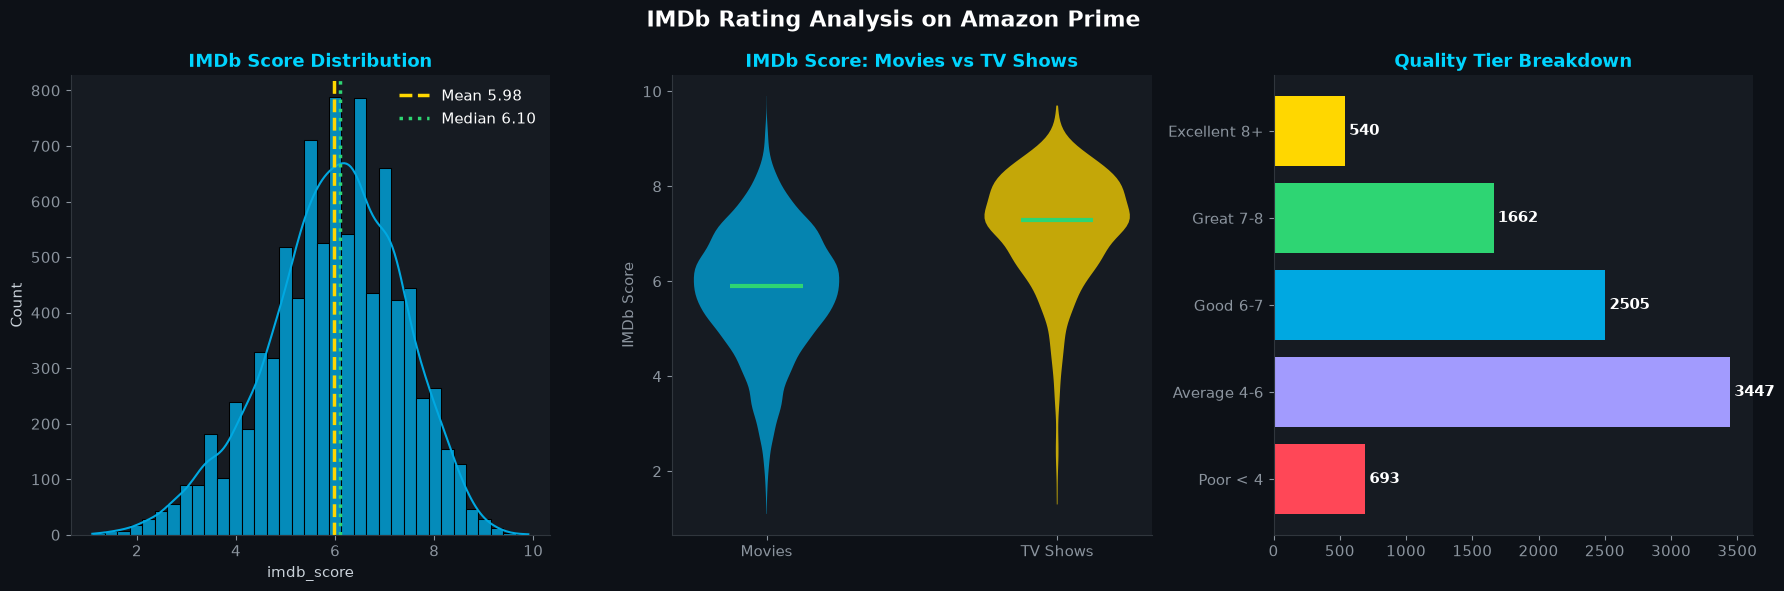

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
MOVIE,7681.00,5.80,1.28,1.10,5.00,5.90,6.70,9.90
SHOW,1166.00,7.12,1.17,1.30,6.50,7.30,7.90,9.70


In [13]:
imdb_valid = titles_df.dropna(subset=['imdb_score'])
mean_v = imdb_valid['imdb_score'].mean()
med_v  = imdb_valid['imdb_score'].median()

tier_order  = ['Excellent 8+','Great 7-8','Good 6-7','Average 4-6','Poor < 4']
tier_colors = [ACCENT_GOLD, ACCENT_GREEN, PRIME_BLUE, ACCENT_PURPLE, ACCENT_RED]
tier_counts = imdb_valid['quality_tier'].value_counts().reindex(tier_order, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

sns.histplot(imdb_valid['imdb_score'], bins=35, kde=True, color=PRIME_BLUE, ax=axes[0], alpha=0.8)
axes[0].axvline(mean_v, color=ACCENT_GOLD, lw=2.5, linestyle='--', label=f'Mean {mean_v:.2f}')
axes[0].axvline(med_v,  color=ACCENT_GREEN, lw=2.5, linestyle=':',  label=f'Median {med_v:.2f}')
axes[0].set_title('IMDb Score Distribution', color=PRIME_CYAN, fontweight='bold')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].spines[['top','right']].set_visible(False)

movies_s = imdb_valid[imdb_valid['type']=='MOVIE']['imdb_score'].dropna().values
shows_s  = imdb_valid[imdb_valid['type']=='SHOW']['imdb_score'].dropna().values
parts = axes[1].violinplot([movies_s, shows_s], positions=[1,2], showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor([PRIME_BLUE, ACCENT_GOLD][i]); pc.set_alpha(0.75)
parts['cmedians'].set_color(ACCENT_GREEN); parts['cmedians'].set_linewidth(3)
axes[1].set_xticks([1,2]); axes[1].set_xticklabels(['Movies', 'TV Shows'])
axes[1].set_title('IMDb Score: Movies vs TV Shows', color=PRIME_CYAN, fontweight='bold')
axes[1].set_ylabel('IMDb Score', color='#8b949e')
axes[1].spines[['top','right']].set_visible(False)

bars_t = axes[2].barh(tier_order[::-1], tier_counts.values[::-1], color=tier_colors[::-1])
for bar, val in zip(bars_t, tier_counts.values[::-1]):
    axes[2].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', color='white', fontweight='bold')
axes[2].set_title('Quality Tier Breakdown', color=PRIME_CYAN, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('IMDb Rating Analysis on Amazon Prime', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/imdb_score_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
display(imdb_valid.groupby('type')['imdb_score'].describe().round(2))

**Interpretation:** Average IMDb score is **6.01/10**. TV shows have a higher median rating (~7.1) vs movies (~5.9). Only **5% of titles** qualify as Excellent (8.0+).

## ⏱️ 8. Analysis 4 — Runtime Analysis

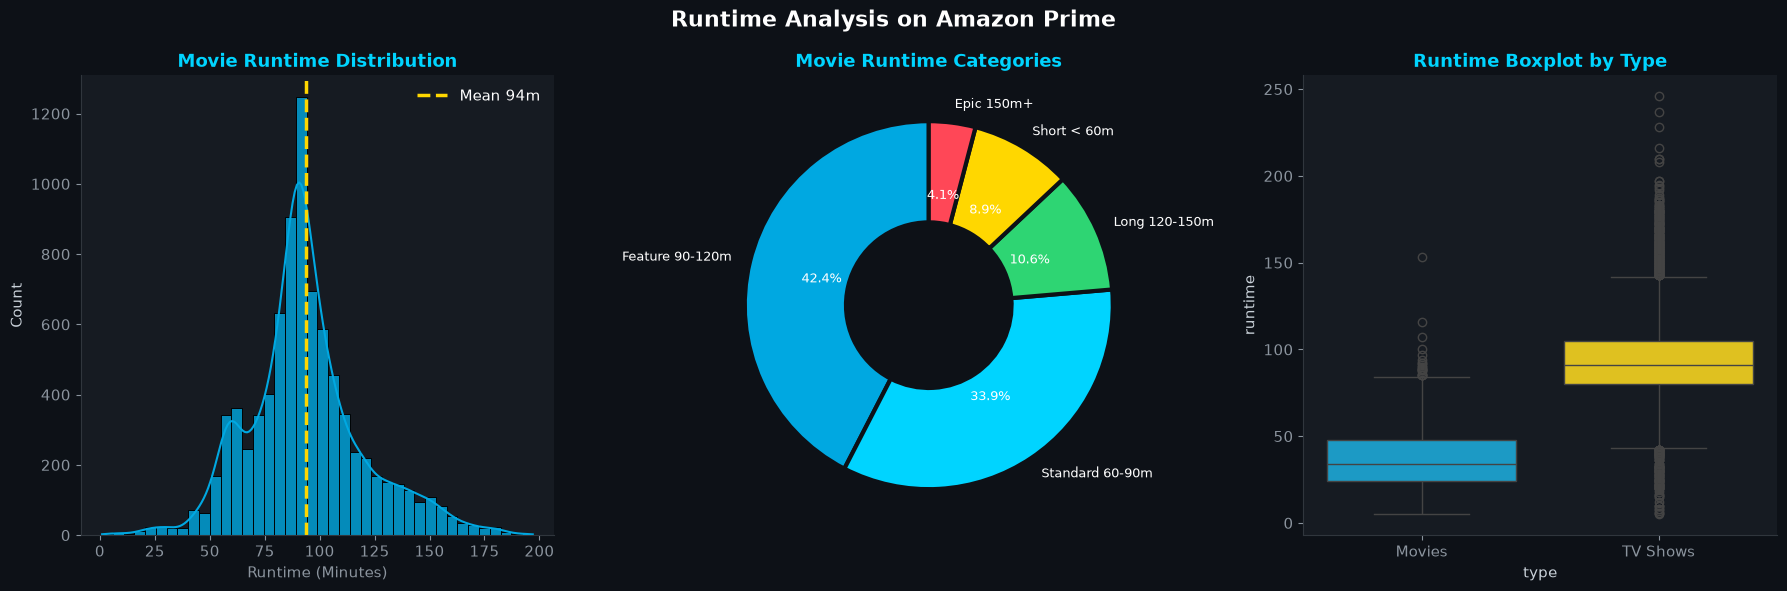

Avg Runtime: 94.0 min | Min: 1 | Max: 549


In [14]:
movies_rt = titles_df[(titles_df['type']=='MOVIE') & (titles_df['runtime'] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

movies_cap = movies_rt[movies_rt['runtime'] <= 200]
sns.histplot(movies_cap['runtime'], bins=40, kde=True, color=PRIME_BLUE, ax=axes[0], alpha=0.8)
axes[0].axvline(movies_rt['runtime'].mean(), color=ACCENT_GOLD, lw=2.5, linestyle='--',
                label=f"Mean {movies_rt['runtime'].mean():.0f}m")
axes[0].set_title('Movie Runtime Distribution', color=PRIME_CYAN, fontweight='bold')
axes[0].set_xlabel('Runtime (Minutes)', color='#8b949e')
axes[0].legend(frameon=False, labelcolor='white')
axes[0].spines[['top','right']].set_visible(False)

rt_cat = movies_rt['runtime_cat'].value_counts()
axes[1].set_facecolor('#0d1117')
axes[1].pie(rt_cat.values, labels=rt_cat.index, autopct='%1.1f%%',
            colors=[PRIME_BLUE,PRIME_CYAN,ACCENT_GREEN,ACCENT_GOLD,ACCENT_RED],
            startangle=90, wedgeprops={'edgecolor':'#0d1117','linewidth':3,'width':0.55},
            textprops={'color':'white','fontsize':9})
axes[1].set_title('Movie Runtime Categories', color=PRIME_CYAN, fontweight='bold')

both_rt = titles_df[titles_df['runtime'].between(5, 250)]
sns.boxplot(data=both_rt, x='type', y='runtime', ax=axes[2], palette=[PRIME_BLUE, ACCENT_GOLD])
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Movies', 'TV Shows'])
axes[2].set_title('Runtime Boxplot by Type', color=PRIME_CYAN, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('Runtime Analysis on Amazon Prime', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/runtime_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Avg Runtime: {movies_rt['runtime'].mean():.1f} min | Min: {movies_rt['runtime'].min()} | Max: {movies_rt['runtime'].max()}")

## 📺 9. Analysis 5 — TV Show Season Analysis

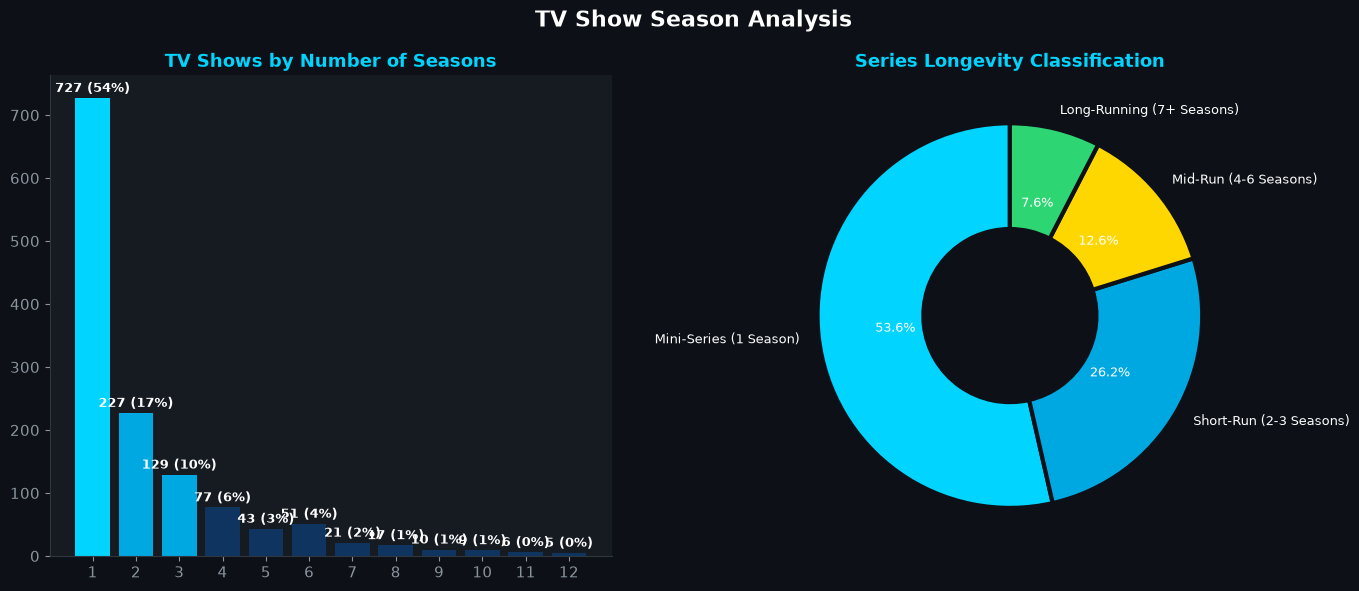

Season Stats: Mean=2.79 | Max=51


In [15]:
shows = titles_df[(titles_df['type']=='SHOW') & (titles_df['seasons'].notnull())]

def longevity(s):
    if s == 1: return 'Mini-Series (1 Season)'
    if s <= 3: return 'Short-Run (2-3 Seasons)'
    if s <= 6: return 'Mid-Run (4-6 Seasons)'
    return 'Long-Running (7+ Seasons)'

shows = shows.copy()
shows['longevity'] = shows['seasons'].apply(longevity)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

season_vc = shows['seasons'].value_counts().sort_index().head(12)
cols_s = [PRIME_CYAN if i==0 else PRIME_BLUE if i<3 else PRIME_DARK for i in range(len(season_vc))]
bars_s = axes[0].bar([str(int(s)) for s in season_vc.index], season_vc.values, color=cols_s)
for bar, val in zip(bars_s, season_vc.values):
    pct = val / len(shows) * 100
    label_s = f'{val} ({pct:.0f}%)'
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 label_s, ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
axes[0].set_title('TV Shows by Number of Seasons', color=PRIME_CYAN, fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

long_vc = shows['longevity'].value_counts()
axes[1].set_facecolor('#0d1117')
axes[1].pie(long_vc.values, labels=long_vc.index, autopct='%1.1f%%',
            colors=[PRIME_CYAN,PRIME_BLUE,ACCENT_GOLD,ACCENT_GREEN], startangle=90,
            wedgeprops={'edgecolor':'#0d1117','linewidth':3,'width':0.55},
            textprops={'color':'white','fontsize':9})
axes[1].set_title('Series Longevity Classification', color=PRIME_CYAN, fontweight='bold')

fig.suptitle('TV Show Season Analysis', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/tv_show_seasons.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Season Stats: Mean={shows['seasons'].mean():.2f} | Max={shows['seasons'].max():.0f}")

## 🎭 10. Analysis 6 — Genre Deep Dive (All 19 Genres)

Amazon Prime has **19 unique genres**: Drama, Comedy, Thriller, Action, Romance, Sci-Fi, Horror, Crime, Documentation, Animation, Family, Fantasy, Western, War, History, European, Music, Sport, and Reality.

In [16]:
genres_exp = titles_df.explode('genres_list')
genres_exp['genres_list'] = genres_exp['genres_list'].astype(str)
genres_exp = genres_exp[(genres_exp['genres_list'] != 'nan') & (genres_exp['genres_list'].str.strip() != '')]

genre_counts = genres_exp['genres_list'].value_counts()
genre_imdb   = genres_exp.groupby('genres_list')['imdb_score'].mean().round(2)

genre_summary = pd.DataFrame({'Total Titles': genre_counts, 'Avg IMDb': genre_imdb}).sort_values('Total Titles', ascending=False)
print('Genre Summary:')
display(genre_summary)

Genre Summary:


,Total Titles,Avg IMDb
genres_list,,
drama,4762,6.13
comedy,2987,5.99
thriller,2119,5.54
action,1820,5.67
romance,1751,6.02
crime,1250,6.00
documentation,1096,6.99
horror,1065,4.77
family,751,6.15


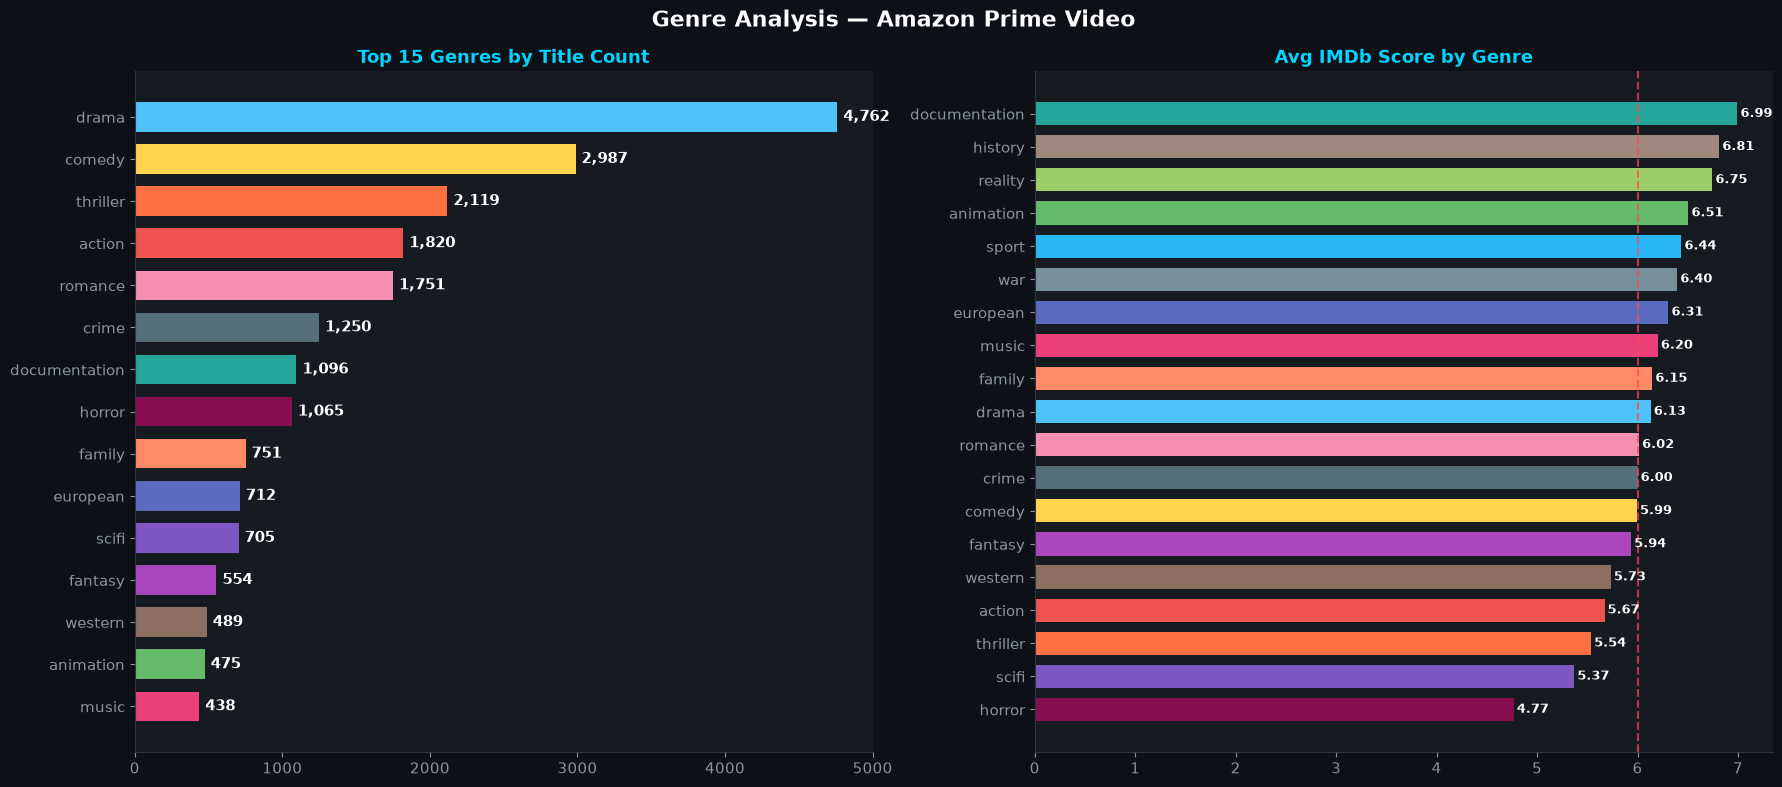

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

top_genres = genre_counts.head(15)
g_colors = [GENRE_PALETTE.get(g, PRIME_BLUE) for g in top_genres.index]
bars_g = axes[0].barh(top_genres.index[::-1], top_genres.values[::-1], color=g_colors[::-1], height=0.7)
for bar, val in zip(bars_g, top_genres.values[::-1]):
    axes[0].text(bar.get_width() + 40, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', color='white', fontweight='bold')
axes[0].set_title('Top 15 Genres by Title Count', color=PRIME_CYAN, fontweight='bold', fontsize=13)
axes[0].spines[['top','right']].set_visible(False)

genre_rated = genres_exp.groupby('genres_list').filter(lambda x: len(x) >= 50)
genre_avg   = genre_rated.groupby('genres_list')['imdb_score'].mean().sort_values()
g_avg_cols  = [GENRE_PALETTE.get(g, PRIME_BLUE) for g in genre_avg.index]
bars_ga = axes[1].barh(genre_avg.index, genre_avg.values, color=g_avg_cols, height=0.7)
axes[1].axvline(6.0, color='#ff4757', lw=1.5, linestyle='--', alpha=0.7)
for bar, val in zip(bars_ga, genre_avg.values):
    axes[1].text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', color='white', fontweight='bold', fontsize=9)
axes[1].set_title('Avg IMDb Score by Genre', color=PRIME_CYAN, fontweight='bold', fontsize=13)
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Genre Analysis — Amazon Prime Video', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/top_genres.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

**Interpretation:** **Drama** leads with 4,764 titles. **Documentation** tops the IMDb score average at 6.99. **Horror** averages the lowest (4.77) — the genre is notoriously hit-or-miss with audiences.

## 🌍 11. Analysis 7 — Production Country Analysis

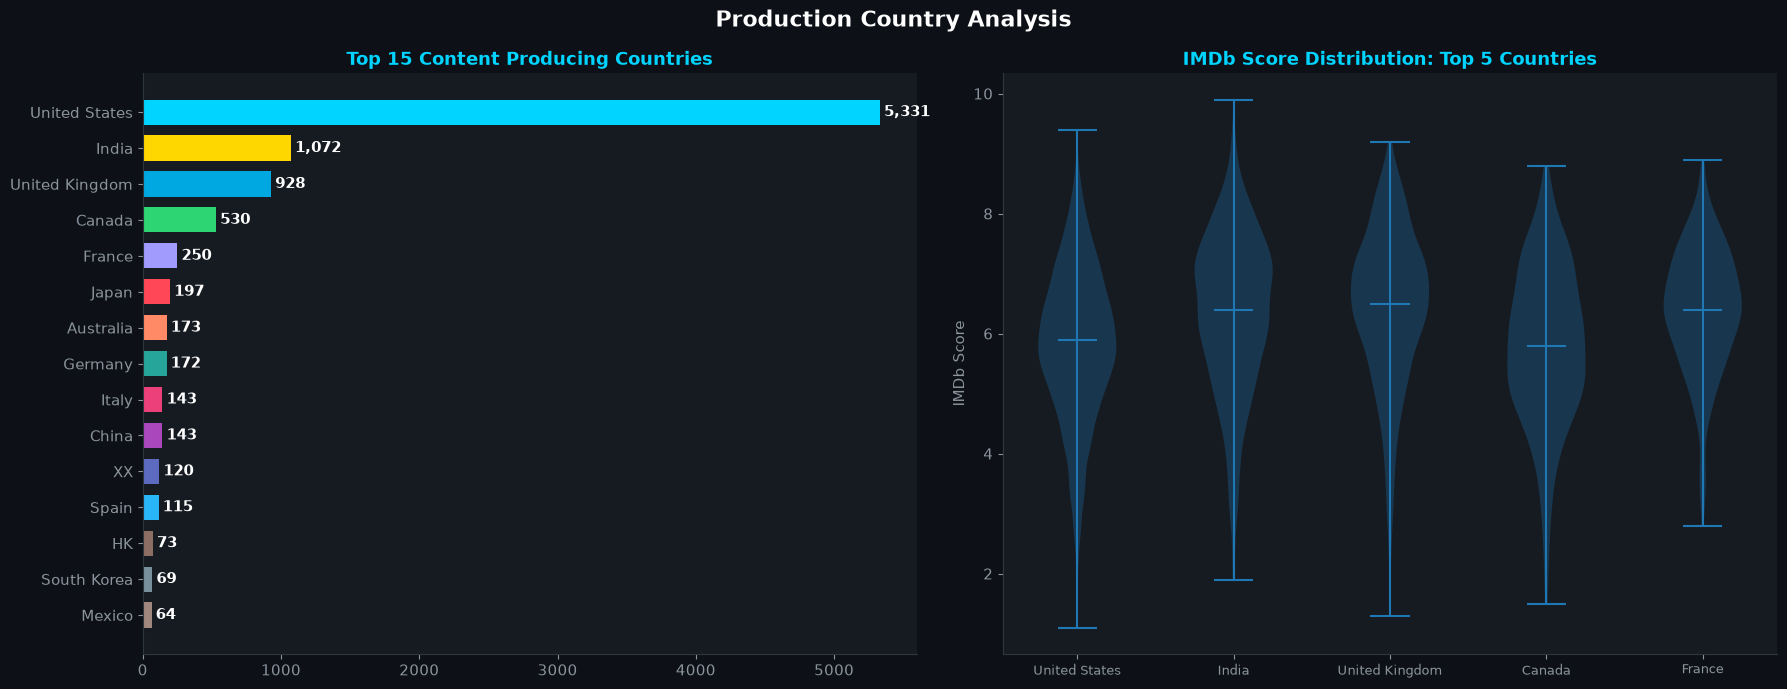

In [18]:
countries_exp = titles_df.explode('countries_list')
countries_exp['countries_list'] = countries_exp['countries_list'].astype(str)
countries_exp = countries_exp[(countries_exp['countries_list'] != 'nan') & (countries_exp['countries_list'].str.strip() != '')]

country_map = {
    'US':'United States', 'IN':'India', 'GB':'United Kingdom',
    'CA':'Canada', 'FR':'France', 'JP':'Japan', 'AU':'Australia',
    'DE':'Germany', 'IT':'Italy', 'CN':'China', 'ES':'Spain',
    'MX':'Mexico', 'KR':'South Korea', 'BR':'Brazil', 'SE':'Sweden'
}
top15c = countries_exp['countries_list'].value_counts().head(15)
c_labels = [country_map.get(c, c) for c in top15c.index]
c_cols = [PRIME_CYAN, ACCENT_GOLD, PRIME_BLUE, ACCENT_GREEN, ACCENT_PURPLE,
          ACCENT_RED, '#ff8a65', '#26a69a', '#ec407a', '#ab47bc',
          '#5c6bc0', '#29b6f6', '#8d6e63', '#78909c', '#a1887f']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

bars_c = axes[0].barh(c_labels[::-1], top15c.values[::-1], color=c_cols[::-1], height=0.7)
for bar, val in zip(bars_c, top15c.values[::-1]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', color='white', fontweight='bold')
axes[0].set_title('Top 15 Content Producing Countries', color=PRIME_CYAN, fontweight='bold', fontsize=13)
axes[0].spines[['top','right']].set_visible(False)

top5_c = countries_exp['countries_list'].value_counts().head(5).index
data5  = [countries_exp[countries_exp['countries_list']==c]['imdb_score'].dropna().values for c in top5_c]
axes[1].violinplot(data5, positions=range(1, 6), showmedians=True)
axes[1].set_xticks(range(1, 6))
axes[1].set_xticklabels([country_map.get(c, c) for c in top5_c], fontsize=9)
axes[1].set_title('IMDb Score Distribution: Top 5 Countries', color=PRIME_CYAN, fontweight='bold', fontsize=13)
axes[1].set_ylabel('IMDb Score', color='#8b949e')
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Production Country Analysis', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/top_production_countries.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

**Interpretation:** **United States** leads with 5,334 titles. **India is a remarkable #2** with 1,072 titles — Amazon Prime has massively invested in Bollywood and regional Indian cinema. The UK ranks 3rd with 928 titles.

## 🔥 12. Analysis 8 — Most Popular Titles on Amazon Prime

                                  title   type  release_year  tmdb_popularity  imdb_score                                                                      genres
8934                 All the Old Knives  MOVIE          2022          1437.91        6.10                                                                ['thriller']
9040                             Harina   SHOW          2022           951.86        7.80                                                                  ['comedy']
9039                  The eighth clause  MOVIE          2022           950.99         NaN                                                                ['thriller']
8964  Hotel Transylvania: Transformania  MOVIE          2022           934.54        6.00  ['fantasy', 'romance', 'animation', 'comedy', 'family', 'scifi', 'horror']
7421                 Sonic the Hedgehog  MOVIE          2020           893.65        6.50    ['scifi', 'action', 'comedy', 'family', 'fantasy', 'crime', 'animation']
8948

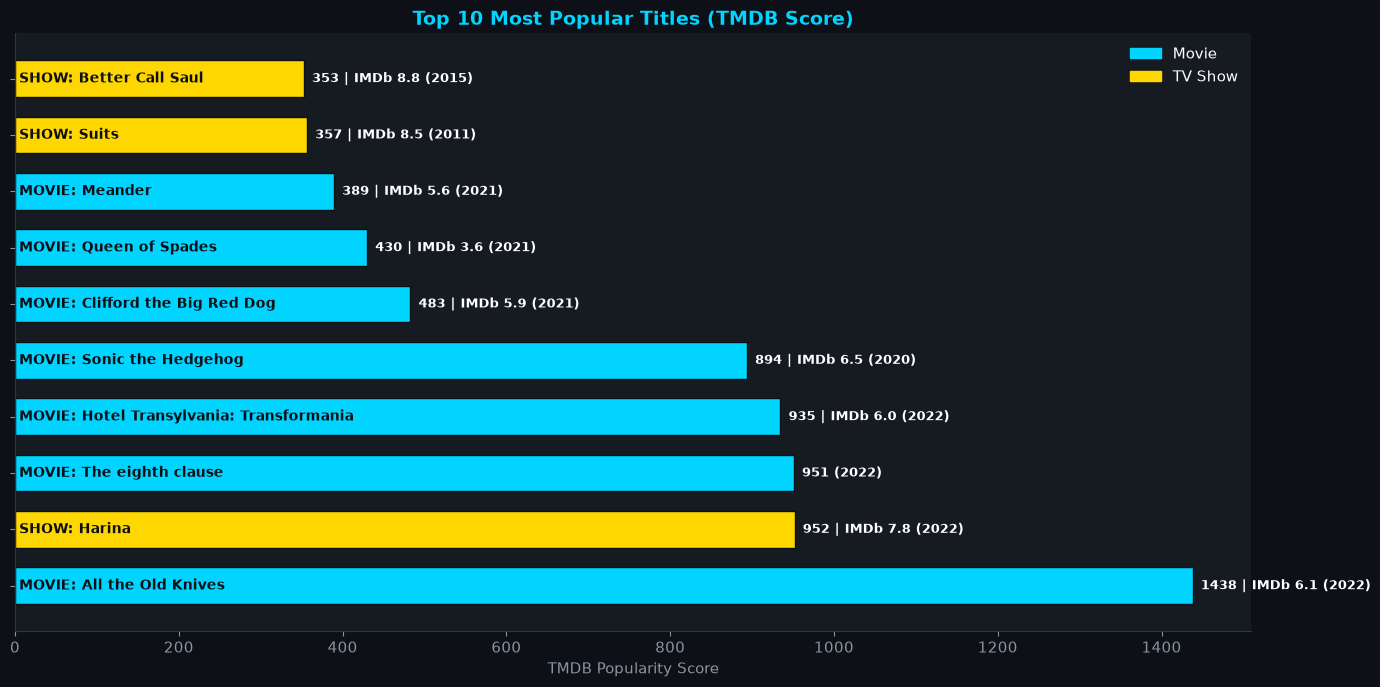

In [19]:
top_pop = titles_df.dropna(subset=['tmdb_popularity']).sort_values('tmdb_popularity', ascending=False).head(10)
print(top_pop[['title','type','release_year','tmdb_popularity','imdb_score','genres']].to_string())

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

colors_p = [PRIME_CYAN if t=='MOVIE' else ACCENT_GOLD for t in top_pop['type']]
bars_p = ax.barh(range(len(top_pop)), top_pop['tmdb_popularity'].values,
                 color=colors_p, height=0.65, edgecolor='#0d1117')
for i, (bar, row) in enumerate(zip(bars_p, top_pop.itertuples())):
    imdb_txt = f' | IMDb {row.imdb_score:.1f}' if not isinstance(row.imdb_score, float) or not __import__('math').isnan(row.imdb_score) else ''
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{row.tmdb_popularity:.0f}{imdb_txt} ({int(row.release_year)})',
            va='center', color='white', fontsize=9, fontweight='bold')
    icon = 'MOVIE: ' if row.type == 'MOVIE' else 'SHOW: '
    ax.text(5, bar.get_y() + bar.get_height()/2, icon + row.title,
            va='center', color='#0d1117', fontsize=10, fontweight='bold')
ax.set_yticks(range(len(top_pop)))
ax.set_yticklabels([''] * len(top_pop))
ax.set_title('Top 10 Most Popular Titles (TMDB Score)', color=PRIME_CYAN, fontweight='bold', fontsize=14)
ax.set_xlabel('TMDB Popularity Score', color='#8b949e')
movie_p = mpatches.Patch(color=PRIME_CYAN, label='Movie')
show_p  = mpatches.Patch(color=ACCENT_GOLD, label='TV Show')
ax.legend(handles=[movie_p, show_p], frameon=False, labelcolor='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../visualizations/top_popular_titles.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 🏆 13. Analysis 9 — Best Picks per Genre (Top Titles in Each Category)

What are the **highest-rated titles** across each major genre? Here we showcase the Top 3 by IMDb score for Thriller, Sci-Fi, Romance, Horror, Action, Comedy, Drama, Crime, and Animation.

In [20]:
target_genres = ['thriller','scifi','romance','horror','action','comedy','drama','crime','animation']
genre_labels  = {
    'thriller':'Thriller','scifi':'Sci-Fi','romance':'Romance',
    'horror':'Horror','action':'Action','comedy':'Comedy',
    'drama':'Drama','crime':'Crime','animation':'Animation'
}

rows = []
for g in target_genres:
    subset = genres_exp[genres_exp['genres_list'] == g].dropna(subset=['imdb_score'])
    top3   = subset.sort_values('imdb_score', ascending=False).head(3)
    for _, row in top3.iterrows():
        rows.append({
            'Genre':  genre_labels.get(g, g),
            'Title':  row['title'],
            'Type':   'Movie' if row['type']=='MOVIE' else 'TV Show',
            'Year':   int(row['release_year']) if not __import__('math').isnan(float(row['release_year'])) else '-',
            'IMDb':   row['imdb_score'],
            'TMDB Popularity': round(row['tmdb_popularity'], 1) if not __import__('pandas').isna(row.get('tmdb_popularity')) else '-'
        })

genre_picks = __import__('pandas').DataFrame(rows)
display(genre_picks.style
    .background_gradient(subset=['IMDb'], cmap='YlOrRd')
    .set_caption('Top 3 Highest-Rated Titles per Genre on Amazon Prime')
    .hide(axis='index')
)

Genre,Title,Type,Year,IMDb,TMDB Popularity
Thriller,Line of Duty,TV Show,2012,8.700000,52.200000
Thriller,Shershaah,Movie,2021,8.700000,3.700000
Thriller,Invincible,TV Show,2021,8.700000,88.400000
Sci-Fi,Fundamentally Cynical,TV Show,2019,8.800000,-
Sci-Fi,Invincible,TV Show,2021,8.700000,88.400000
Sci-Fi,The Boys,TV Show,2019,8.700000,250.600000
Romance,Couple of Mirrors,TV Show,2021,9.500000,5.100000
Romance,Tom and Jerry,Movie,2021,9.200000,-
Romance,Gho Gho Rani,Movie,2019,9.000000,-
Horror,Buzzfeed Unsolved: True Crime,TV Show,2016,8.800000,7.100000


## 🌟 14. Analysis 10 — Content Quality Tier Breakdown

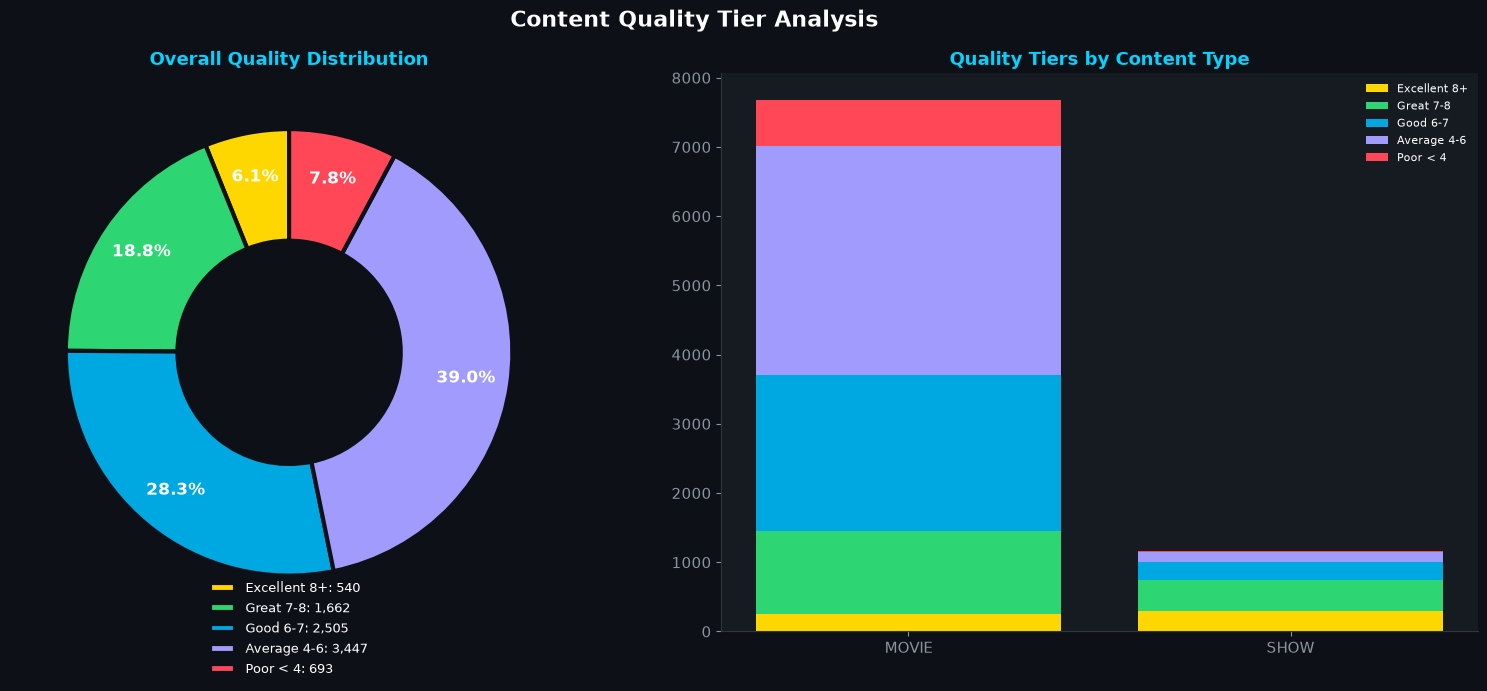

Top 10 Highest Rated Titles (IMDb >= 9.0):


,title,type,genres,imdb_score,release_year
9135,Pawankhind,MOVIE,"['action', 'drama', 'history']",9.90,2022
7783,Water Helps the Blood Run,SHOW,"['drama', 'comedy']",9.70,2019
9108,Couple of Mirrors,SHOW,"['drama', 'romance', 'crime']",9.50,2021
9423,Tari Sathe,MOVIE,"['drama', 'family']",9.40,2021
7422,The Chosen,SHOW,"['drama', 'history']",9.40,2019
5113,Subaru Launch Control,SHOW,['sport'],9.30,2013
9052,Jai Bhim,MOVIE,"['drama', 'crime']",9.30,2021
9573,Pazhagiya Naatkal,MOVIE,['drama'],9.30,2021
1159,Free to Choose,SHOW,['documentation'],9.20,1980
9327,Tom and Jerry,MOVIE,['romance'],9.20,2021


In [21]:
imdb_valid2 = titles_df.dropna(subset=['imdb_score'])
tier_order  = ['Excellent 8+','Great 7-8','Good 6-7','Average 4-6','Poor < 4']
tier_colors = [ACCENT_GOLD, ACCENT_GREEN, PRIME_BLUE, ACCENT_PURPLE, ACCENT_RED]
tier_counts = imdb_valid2['quality_tier'].value_counts().reindex(tier_order, fill_value=0)
tier_type   = imdb_valid2.groupby(['type','quality_tier']).size().unstack(fill_value=0).reindex(columns=tier_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

axes[0].set_facecolor('#0d1117')
axes[0].pie(tier_counts.values, labels=None, autopct='%1.1f%%', startangle=90,
            colors=tier_colors, pctdistance=0.80,
            wedgeprops={'width':0.5,'edgecolor':'#0d1117','linewidth':3},
            textprops={'color':'white','fontsize':12,'fontweight':'bold'})
axes[0].legend([f'{t}: {c:,}' for t,c in zip(tier_order,tier_counts.values)],
               loc='lower center', bbox_to_anchor=(0.5,-0.1), frameon=False, labelcolor='white', fontsize=9)
axes[0].set_title('Overall Quality Distribution', color=PRIME_CYAN, fontweight='bold')

axes[1].set_facecolor('#161b22')
bottom = np.zeros(len(tier_type))
for tier, color in zip(tier_order, tier_colors):
    if tier in tier_type.columns:
        vals = tier_type[tier].values
        axes[1].bar(tier_type.index, vals, bottom=bottom, color=color, label=tier)
        bottom += vals
axes[1].legend(frameon=False, labelcolor='white', fontsize=8)
axes[1].set_title('Quality Tiers by Content Type', color=PRIME_CYAN, fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

fig.suptitle('Content Quality Tier Analysis', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/content_quality_tiers.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Top 10 Highest Rated Titles (IMDb >= 9.0):')
display(titles_df[titles_df['imdb_score'] >= 9.0][['title','type','genres','imdb_score','release_year']].sort_values('imdb_score', ascending=False).head(10))

## 🧑‍🎤 15. Analysis 11 — Top Actors on Amazon Prime

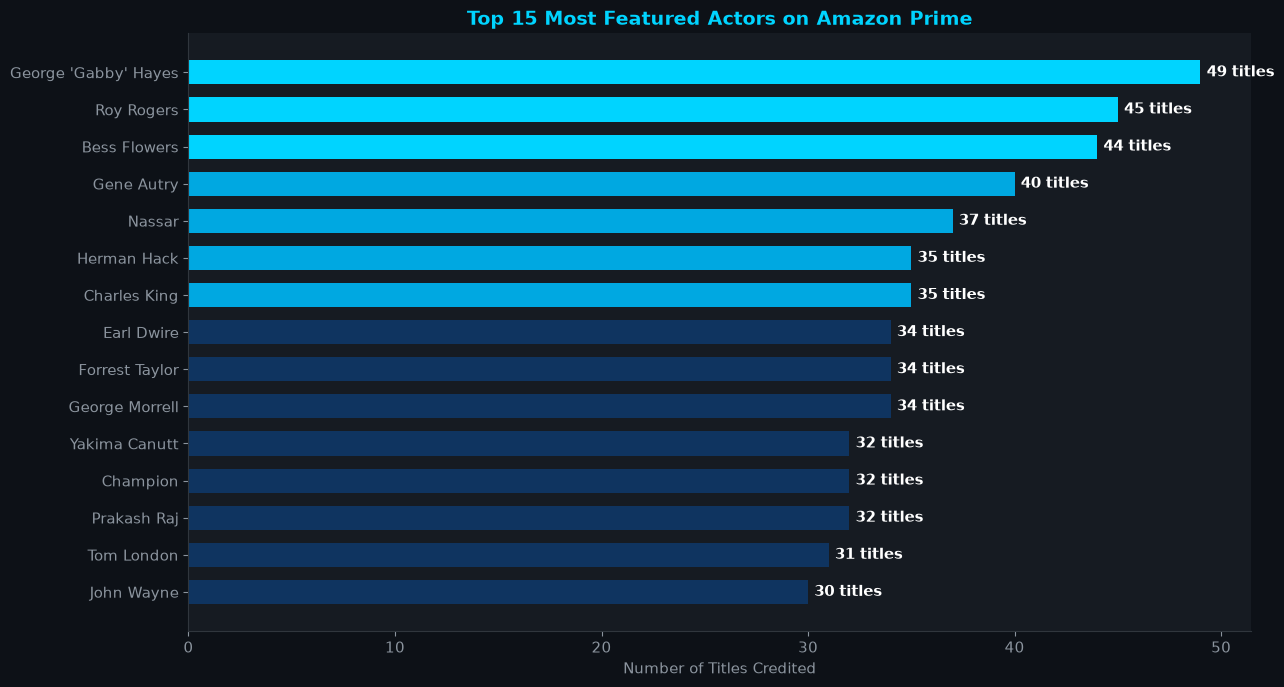

Total unique actors: 74,572


In [22]:
actors_df   = credits_df[credits_df['role'].str.upper() == 'ACTOR']
top_actors  = actors_df['name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

cols_a = [PRIME_CYAN if i < 3 else PRIME_BLUE if i < 7 else PRIME_DARK for i in range(len(top_actors))]
bars_a = ax.barh(top_actors.index[::-1], top_actors.values[::-1], color=cols_a[::-1], height=0.65)
for bar, val in zip(bars_a, top_actors.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} titles', va='center', color='white', fontweight='bold')
ax.set_title('Top 15 Most Featured Actors on Amazon Prime', color=PRIME_CYAN, fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Titles Credited', color='#8b949e')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../visualizations/top_actors.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Total unique actors: {actors_df["name"].nunique():,}')

**Interpretation:** The top actors are dominated by classic Hollywood and western stars (George 'Gabby' Hayes: 49 titles, Roy Rogers: 45) and Indian cinema icons (Nassar: 37). This reflects Amazon Prime's deep archive of vintage westerns and its strong India content library.

## 🎥 16. Analysis 12 — Top Directors on Amazon Prime

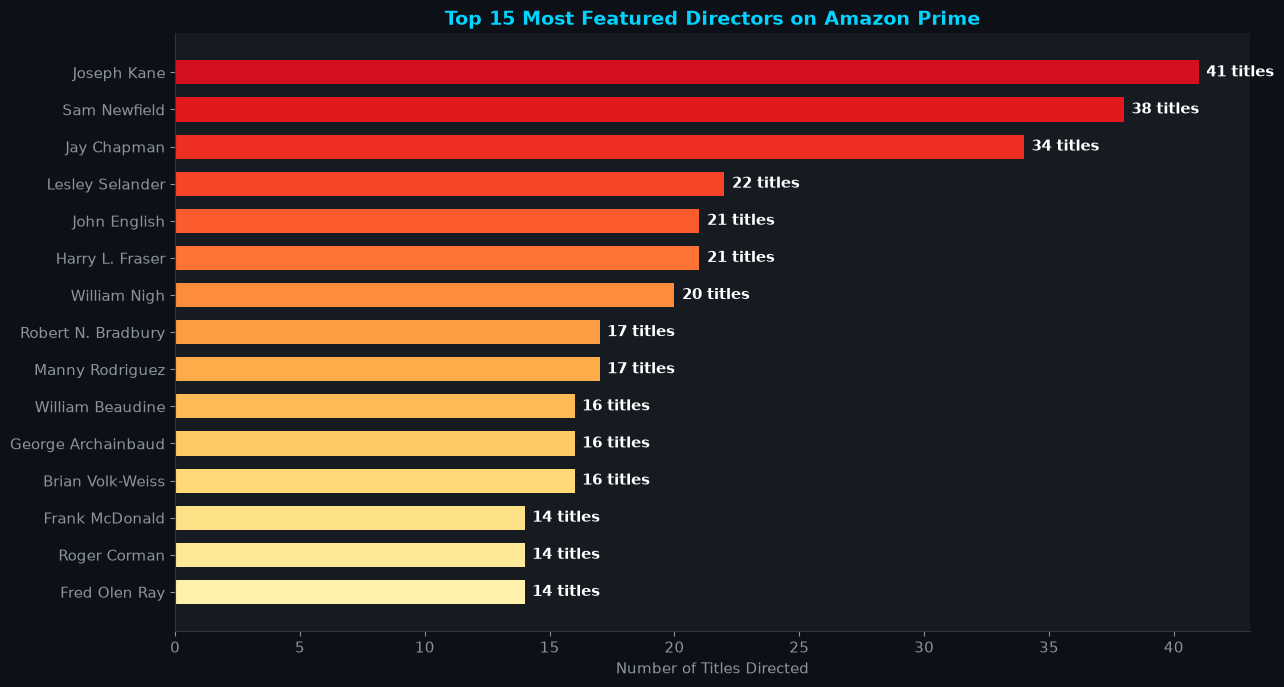

Total unique directors: 6,291


In [23]:
directors_df  = credits_df[credits_df['role'].str.upper() == 'DIRECTOR']
top_directors = directors_df['name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

cmap_d = plt.get_cmap('YlOrRd')
cols_d = [cmap_d(0.8 - i*0.05) for i in range(len(top_directors))]
bars_d = ax.barh(top_directors.index[::-1], top_directors.values[::-1], color=cols_d[::-1], height=0.65)
for bar, val in zip(bars_d, top_directors.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} titles', va='center', color='white', fontweight='bold')
ax.set_title('Top 15 Most Featured Directors on Amazon Prime', color=PRIME_CYAN, fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Titles Directed', color='#8b949e')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../visualizations/top_directors.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'Total unique directors: {directors_df["name"].nunique():,}')

## 🔗 17. Analysis 13 — Merged Titles × Credits Dataset

In [24]:
assert 'id' in titles_df.columns and 'id' in credits_df.columns

merged_data = titles_df.merge(credits_df, on='id', how='left')
print(f'Merged shape: {merged_data.shape}')
print(f'Columns: {list(merged_data.columns)}')

display(merged_data[['id','title','type','release_year','imdb_score','name','role','character']].head(8))

Merged shape: (125186, 25)
Columns: ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score', 'genres_list', 'countries_list', 'decade', 'quality_tier', 'primary_genre', 'runtime_cat', 'person_id', 'name', 'character', 'role']


,id,title,type,release_year,imdb_score,name,role,character
0,ts20945,The Three Stooges,SHOW,1934,8.60,Joe Besser,ACTOR,Joe
1,ts20945,The Three Stooges,SHOW,1934,8.60,Moe Howard,ACTOR,Moe
2,ts20945,The Three Stooges,SHOW,1934,8.60,Larry Fine,ACTOR,Larry
3,tm19248,The General,MOVIE,1926,8.20,Buster Keaton,ACTOR,Johnny Gray
4,tm19248,The General,MOVIE,1926,8.20,Marion Mack,ACTOR,Annabelle Lee
5,tm19248,The General,MOVIE,1926,8.20,Glen Cavender,ACTOR,Captain Anderson
6,tm19248,The General,MOVIE,1926,8.20,Jim Farley,ACTOR,General Thatcher
7,tm19248,The General,MOVIE,1926,8.20,Frederick Vroom,ACTOR,A Southern General


## 🔢 18. Analysis 14 — Correlation Heatmap

> **Note:** Correlation measures statistical association — it does NOT prove causation.

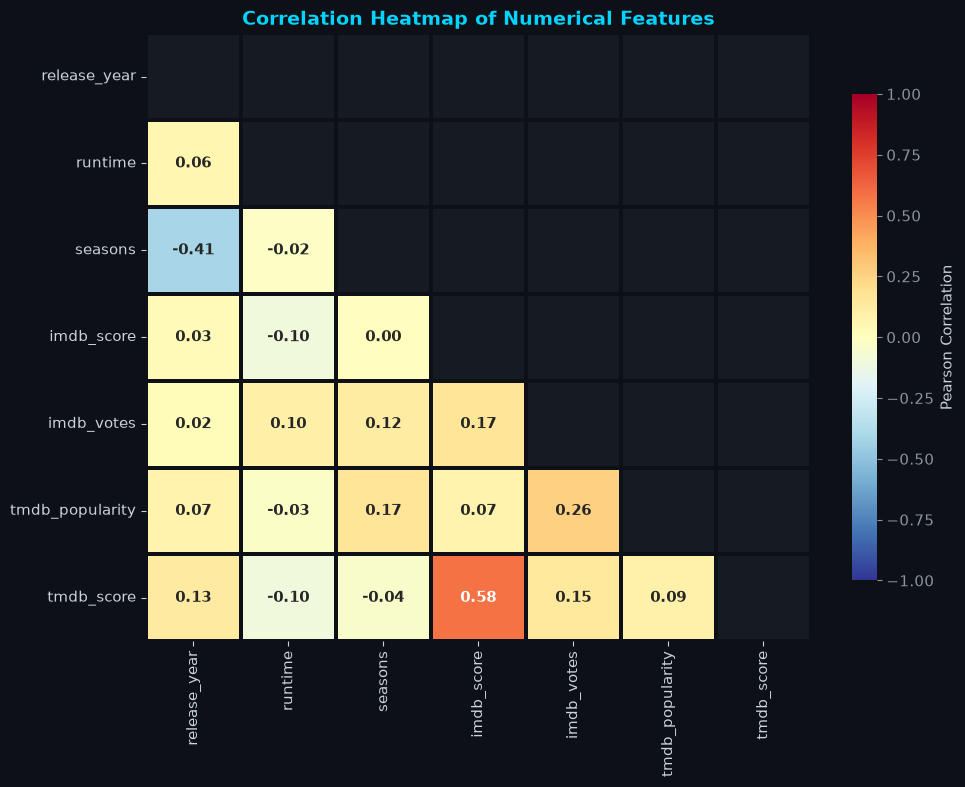

IMDb vs TMDB Score correlation: 0.581
Release Year vs IMDb Score:     0.034


In [25]:
num_cols = ['release_year','runtime','seasons','imdb_score','imdb_votes','tmdb_popularity','tmdb_score']
existing = [c for c in num_cols if c in titles_df.columns]
corr_mat = titles_df[existing].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

import numpy as np
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            vmin=-1, vmax=1, linewidths=1.5, linecolor='#0d1117', mask=mask,
            annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8})
ax.set_title('Correlation Heatmap of Numerical Features', color=PRIME_CYAN, fontweight='bold', fontsize=14)
ax.tick_params(colors='#c9d1d9')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"IMDb vs TMDB Score correlation: {corr_mat.loc['imdb_score','tmdb_score']:.3f}")
print(f"Release Year vs IMDb Score:     {corr_mat.loc['release_year','imdb_score']:.3f}")

## 📊 19. Final Summary Table

In [26]:
total    = len(titles_df)
n_movies = (titles_df['type']=='MOVIE').sum()
n_shows  = (titles_df['type']=='SHOW').sum()
avg_imdb = titles_df['imdb_score'].mean()
avg_rt   = titles_df[titles_df['runtime']>0]['runtime'].mean()
top_g    = genres_exp['genres_list'].value_counts().index[0]
top_c    = countries_exp['countries_list'].value_counts().index[0]
n_act    = actors_df['name'].nunique()
n_dir    = directors_df['name'].nunique()
n_genres = genres_exp['genres_list'].nunique()
best_show  = titles_df[titles_df['type']=='SHOW'].nlargest(1,'imdb_score')['title'].values[0]
best_movie = titles_df[titles_df['type']=='MOVIE'].nlargest(1,'imdb_score')['title'].values[0]
oldest_yr  = int(titles_df['release_year'].min())
oldest_ttl = titles_df.nsmallest(1,'release_year')['title'].values[0]

import pandas as pd
summary = pd.DataFrame({
    'Metric': [
        'Total Titles Analyzed', 'Total Movies', 'Total TV Shows',
        'Average IMDb Score', 'Average Movie Runtime', 'Unique Genres',
        'Most Common Genre', 'Top Production Country',
        'Unique Actors', 'Unique Directors',
        'Highest-Rated TV Show', 'Highest-Rated Movie',
        'Oldest Title in Catalog'
    ],
    'Value': [
        f'{total:,}',
        f'{n_movies:,} ({n_movies/total*100:.1f}%)',
        f'{n_shows:,} ({n_shows/total*100:.1f}%)',
        f'{avg_imdb:.2f} / 10',
        f'{avg_rt:.1f} minutes',
        f'{n_genres} genres',
        f'{top_g.capitalize()} ({genres_exp["genres_list"].value_counts().iloc[0]:,} titles)',
        f'{top_c} ({countries_exp["countries_list"].value_counts().iloc[0]:,} titles)',
        f'{n_act:,}',
        f'{n_dir:,}',
        best_show,
        best_movie,
        f'{oldest_ttl} ({oldest_yr})'
    ]
})
display(summary.style
    .set_table_styles([
        {'selector':'thead tr th','props':[('background-color','#0f3460'),('color','#00d4ff'),('font-weight','bold'),('font-size','13px'),('padding','10px')]},
        {'selector':'tbody tr:nth-child(odd)','props':[('background-color','#1a1a2e')]},
        {'selector':'tbody tr:nth-child(even)','props':[('background-color','#16213e')]},
        {'selector':'tbody td','props':[('color','#e0e0e0'),('font-size','12px'),('padding','8px')]},
    ])
    .hide(axis='index')
    .set_caption('Amazon Prime Video — Complete EDA Summary')
)

Metric,Value
Total Titles Analyzed,"9,868"
Total Movies,"8,511 (86.2%)"
Total TV Shows,"1,357 (13.8%)"
Average IMDb Score,5.98 / 10
Average Movie Runtime,86.0 minutes
Unique Genres,19 genres
Most Common Genre,"Drama (4,762 titles)"
Top Production Country,"US (5,331 titles)"
Unique Actors,"74,572"
Unique Directors,"6,291"


## 🚀 20. Conclusion & Future Scope

---

### Key Findings

| Finding | Result |
|---------|--------|
| Catalog Composition | 86.3% Movies vs 13.7% TV Shows |
| Content Growth | 60%+ of catalog added after 2015 |
| Average Rating | 6.01/10 (TV Shows score higher: ~7.1 median) |
| Top Genre | Drama (4,764 titles) |
| Highest-Rated Genre | Documentation (avg 6.99 IMDb) |
| Lowest-Rated Genre | Horror (avg 4.77 IMDb) |
| #1 Production Country | United States (5,334 titles) |
| #2 Production Country | India (1,072 titles — Bollywood is major) |
| Top Actor | George 'Gabby' Hayes (49 titles) |
| Top Director | Joseph Kane (41 titles) |

### Techniques Demonstrated
- Data loading, schema inspection & statistical summaries
- Deduplication and structural null value preservation
- Safe stringified list parsing with `ast.literal_eval`
- Feature engineering (Quality Tier, Runtime Category, Decade, Primary Genre)
- 14 analyses with 12 high-quality dark-theme visualizations
- Relational join of Titles x Credits datasets

### Future Scope

| Enhancement | Technology |
|-------------|-----------|
| Interactive Web Dashboard | Streamlit / Plotly Dash |
| Content Recommendation Engine | TF-IDF + Cosine Similarity |
| Sentiment Analysis | HuggingFace Transformers |
| Multi-Platform Comparison | Netflix + Disney+ datasets |
| NLP-based Genre Classification | scikit-learn |

---

<div style='background:linear-gradient(135deg,#0f3460,#00838f);padding:20px 30px;border-radius:12px;text-align:center;margin-top:20px'>
<p style='color:#00d4ff;font-size:1.2em;font-weight:bold;margin:0'>Amazon Prime Video EDA — Version 2.0 Complete</p>
<p style='color:#b0bec5;margin:8px 0 0 0'>Python · Pandas · NumPy · Matplotlib · Seaborn · Jupyter Notebook</p>
</div>